<a href="https://colab.research.google.com/github/Fahrisetiadarma/DataAnalytics/blob/main/Clustering/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latar Belakang

Perusahaan kartu kredit saat ini menghadapi tantangan dalam memahami pola perilaku transaksi nasabah secara mendalam. Dengan volume transaksi yang tinggi dan beragam mulai dari ridesharing, online gifts, hingga aktivitas mencurigakan yang terdeteksi sebagai fraud. Tim risiko dan pemasaran kesulitan merancang strategi yang tepat sasaran. Data historis transaksi yang tercatat, termasuk informasi limit kredit, jumlah transaksi, kategori merchant, serta flag fraud, menjadi aset berharga yang belum sepenuhnya dimanfaatkan untuk segmentasi nasabah yang lebih cerdas

# Install and Load Packages

In [49]:
!pip install yellowbrick

In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial import ConvexHull
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

# Load Dataset

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
df = pd.read_csv('/content/drive/MyDrive/DS/transactions.csv')

# RFM Analysis

## Data Preprocessing

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641914 entries, 0 to 641913
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   accountNumber             641914 non-null  int64  
 1   customerId                641914 non-null  int64  
 2   creditLimit               641914 non-null  int64  
 3   availableMoney            641914 non-null  float64
 4   transactionDateTime       641914 non-null  object 
 5   transactionAmount         641914 non-null  float64
 6   merchantName              641914 non-null  object 
 7   acqCountry                638001 non-null  object 
 8   merchantCountryCode       641290 non-null  object 
 9   posEntryMode              638569 non-null  float64
 10  posConditionCode          641627 non-null  float64
 11  merchantCategoryCode      641914 non-null  object 
 12  currentExpDate            641914 non-null  object 
 13  accountOpenDate           641914 non-null  o

In [54]:
df

,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,...,accountOpenDate,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,isFraud,currentBalance,cardPresent,expirationDateKeyInMatch
0,733493772,733493772,5000,5000.00,2016-01-08T19:04:50,111.33,Lyft,US,US,5.0,...,3/8/2014,3/8/2014,492,492,9184,PURCHASE,True,0.00,False,False
1,733493772,733493772,5000,4888.67,2016-01-09T22:32:39,24.75,Uber,US,US,9.0,...,3/8/2014,3/8/2014,492,492,9184,PURCHASE,False,111.33,False,False
2,733493772,733493772,5000,4863.92,2016-01-11T13:36:55,187.40,Lyft,US,US,5.0,...,3/8/2014,3/8/2014,492,492,9184,PURCHASE,False,136.08,False,False
3,733493772,733493772,5000,4676.52,2016-01-11T22:47:46,227.34,Lyft,US,US,2.0,...,3/8/2014,3/8/2014,492,492,9184,PURCHASE,True,323.48,False,False
4,733493772,733493772,5000,4449.18,2016-01-16T01:41:11,0.00,Lyft,US,US,2.0,...,3/8/2014,3/8/2014,492,492,9184,ADDRESS_VERIFICATION,False,550.82,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641909,186770399,186770399,7500,2574.02,2016-12-04T12:29:21,5.37,Apple iTunes,US,US,5.0,...,4/11/2015,3/6/2016,127,127,5432,PURCHASE,False,4925.98,False,False
641910,186770399,186770399,7500,2568.65,2016-12-09T04:20:35,223.70,Blue Mountain eCards,US,US,9.0,...,4/11/2015,3/6/2016,127,127,5432,PURCHASE,False,4931.35,False,False
641911,186770399,186770399,7500,2344.95,2016-12-16T07:58:23,138.42,Fresh Flowers,US,US,2.0,...,4/11/2015,3/6/2016,127,127,5432,PURCHASE,False,5155.05,False,False
641912,186770399,186770399,7500,2206.53,2016-12-19T02:30:35,16.31,abc.com,US,US,9.0,...,4/11/2015,3/6/2016,127,127,5432,PURCHASE,False,5293.47,False,False


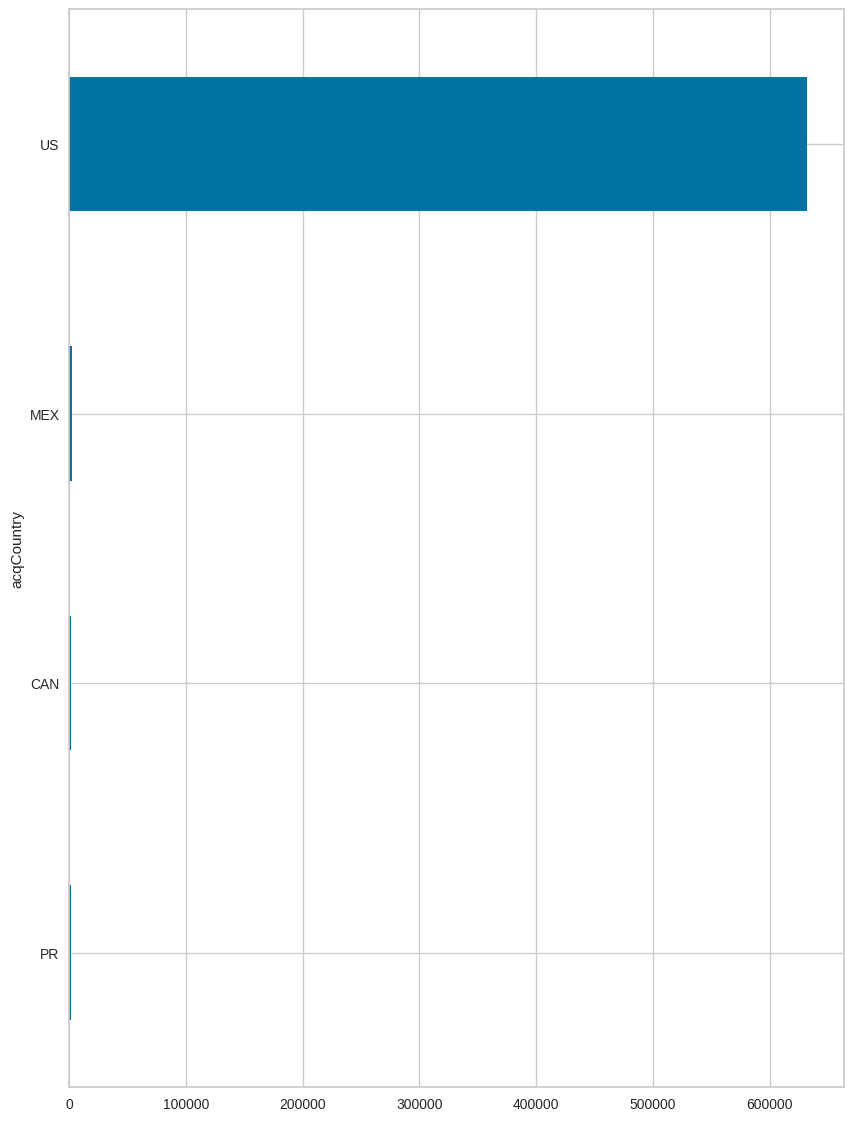

In [55]:
plt.figure(figsize=(10,14))
df['acqCountry'].value_counts(ascending=True).plot(kind='barh');

Only pick from US

In [56]:
df = df.query('acqCountry == "US"')

Check null values

In [57]:
df.isnull().sum()

,0
accountNumber,0
customerId,0
creditLimit,0
availableMoney,0
transactionDateTime,0
transactionAmount,0
merchantName,0
acqCountry,0
merchantCountryCode,1
posEntryMode,3256


In [58]:
df_clean = df.dropna(how='any')

Recheck Null Data

In [59]:
df_clean.isnull().sum()

,0
accountNumber,0
customerId,0
creditLimit,0
availableMoney,0
transactionDateTime,0
transactionAmount,0
merchantName,0
acqCountry,0
merchantCountryCode,0
posEntryMode,0


In [60]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 628193 entries, 0 to 641913
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   accountNumber             628193 non-null  int64  
 1   customerId                628193 non-null  int64  
 2   creditLimit               628193 non-null  int64  
 3   availableMoney            628193 non-null  float64
 4   transactionDateTime       628193 non-null  object 
 5   transactionAmount         628193 non-null  float64
 6   merchantName              628193 non-null  object 
 7   acqCountry                628193 non-null  object 
 8   merchantCountryCode       628193 non-null  object 
 9   posEntryMode              628193 non-null  float64
 10  posConditionCode          628193 non-null  float64
 11  merchantCategoryCode      628193 non-null  object 
 12  currentExpDate            628193 non-null  object 
 13  accountOpenDate           628193 non-null  object

In [61]:
date_columns = [
    'transactionDateTime',
    'currentExpDate',
    'accountOpenDate',
    'dateOfLastAddressChange'
]

for col in date_columns:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

/tmp/ipykernel_418/1730426336.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
/tmp/ipykernel_418/1730426336.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
/tmp/ipykernel_418/1730426336.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

In [62]:
df_clean['transactionDateTime'] = pd.to_datetime(df_clean['transactionDateTime'])

/tmp/ipykernel_418/4221503919.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['transactionDateTime'] = pd.to_datetime(df_clean['transactionDateTime'])


In [63]:
df_clean['transactionDateTime'].max()

Timestamp('2016-12-30 23:59:27')

In [65]:
analysis_date = df_clean['transactionDateTime'].max()

Create data object for rfm modeling

In [66]:
rfm = (
    df_clean
    .groupby('customerId')
    .agg(
        Recency=('transactionDateTime', lambda x: (analysis_date - x.max()).days),
        Frequency=('transactionDateTime', 'count'),
        Monetary=('transactionAmount', 'sum')
    )
    .reset_index()
)

In [67]:
rfm.rename(columns={'transactionDateTime': 'Recency',
                         'transactionDateTime': 'Frequency',
                         'transactionAmount': 'Monetary'}, inplace=True)

Check final data for customer segmentation

In [68]:
rfm

,customerId,Recency,Frequency,Monetary
0,100547107,0,84,10950.11
1,100634414,5,22,1500.86
2,100973869,8,45,6086.33
3,101192712,5,20,592.68
4,101548993,13,29,1555.24
...,...,...,...,...
4995,999273501,1,8,78.94
4996,999275549,0,225,31757.82
4997,999789077,2,69,7102.10
4998,999984515,2,32,2893.21


Top 10 Customers by Transaction Frequency

/tmp/ipykernel_418/3598765040.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


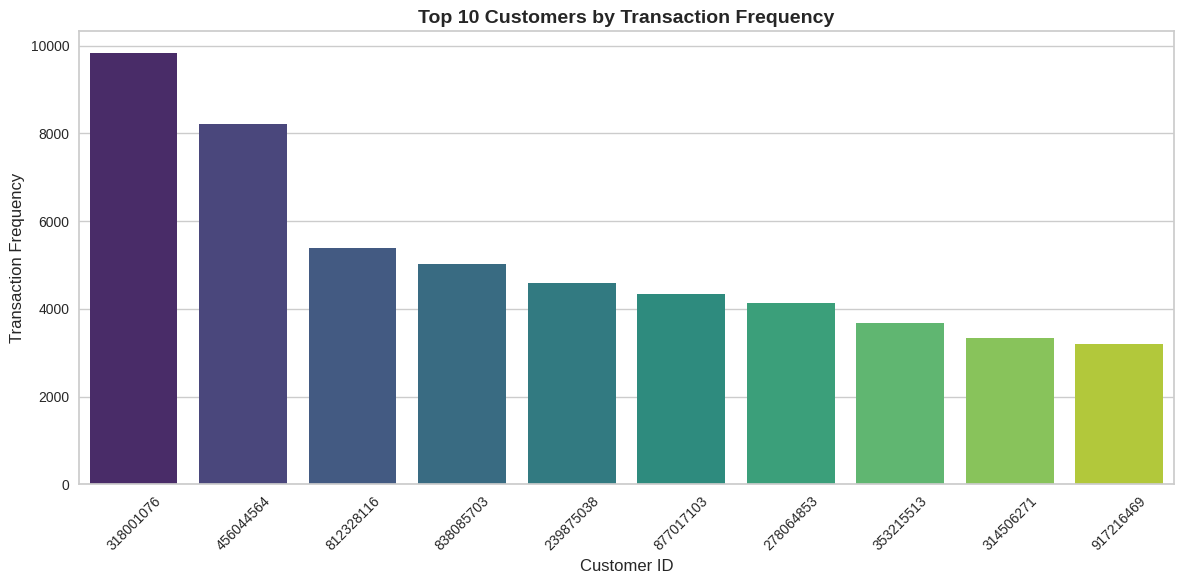

In [69]:
customer_frequency = df_clean['customerId'].value_counts().reset_index()
customer_frequency.columns = ['customerId', 'Frequency']
top_10_customers_by_frequency = customer_frequency.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x='customerId',
    y='Frequency',
    data=top_10_customers_by_frequency,
    palette='viridis',
    order=top_10_customers_by_frequency['customerId']
)

plt.title('Top 10 Customers by Transaction Frequency', fontsize=14, fontweight='bold')
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Transaction Frequency', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Proporsi Transaksi: Siang vs Malam

/tmp/ipykernel_418/3050364900.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['hour'] = df_clean['transactionDateTime'].dt.hour
/tmp/ipykernel_418/3050364900.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['time_pattern'] = df_clean['hour'].apply(lambda x: 'Siang' if 6 <= x < 18 else 'Malam')


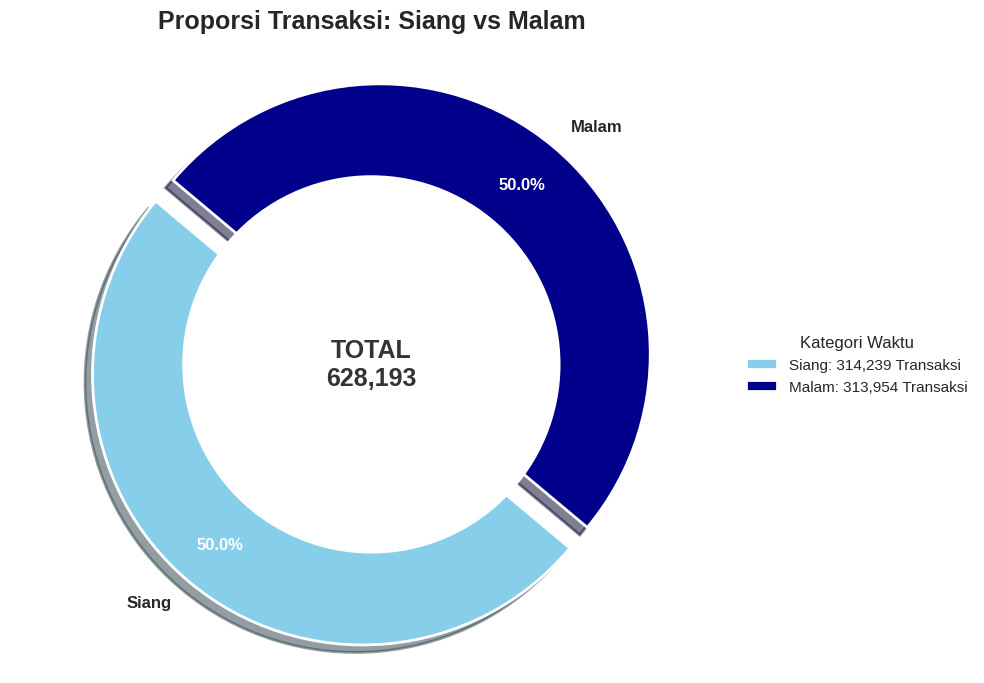

In [71]:
import matplotlib.pyplot as plt

# Create the 'time_pattern' column
df_clean['hour'] = df_clean['transactionDateTime'].dt.hour
df_clean['time_pattern'] = df_clean['hour'].apply(lambda x: 'Siang' if 6 <= x < 18 else 'Malam')

time_pattern_counts = df_clean['time_pattern'].value_counts()
labels = time_pattern_counts.index
sizes = time_pattern_counts.values
total_transaksi = sum(sizes)

color_map = {'Siang': '#87CEEB', 'Malam': '#00008B'}
colors = [color_map[label] for label in labels]

plt.figure(figsize=(10, 7))

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    explode=[0.05] * len(labels),
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)

for autotext in autotexts:
    autotext.set_color('white')

centre_circle = plt.Circle((0,0), 0.70, fc='white', linewidth=1.25)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.text(0, 0, f'TOTAL\n{total_transaksi:,}', ha='center', va='center',
         fontsize=18, fontweight='bold', color='#333333')

plt.legend(
    wedges,
    [f'{l}: {s:,} Transaksi' for l, s in zip(labels, sizes)],
    title="Kategori Waktu",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)

plt.title('Proporsi Transaksi: Siang vs Malam', fontsize=18, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

## RFM Segmentation

Create RFM segmentation

In [72]:
r_labels = range(4, 0, -1)
f_labels = range(1, 5)
m_labels = range(1, 5)

r_groups = pd.qcut(rfm['Recency'], q=4, labels = r_labels)
f_groups = pd.qcut(rfm['Frequency'], q=4, labels = f_labels)
m_groups = pd.qcut(rfm['Monetary'], q=4, labels = m_labels)

In [73]:
list(range(1, 5))

[1, 2, 3, 4]

In [74]:
list(range(4, 0, -1))

[4, 3, 2, 1]

In [75]:
rfm = rfm.assign(R = r_groups.values, F = f_groups.values, M = m_groups.values)

In [76]:
rfm['rfm_score'] = rfm[['R','F','M']].apply(
    lambda x: ''.join(x.astype(str)),
    axis=1
)

In [77]:
rfm['rfm_score'] = rfm['rfm_score'].astype('int')

Check final result

In [78]:
rfm.head()

,customerId,Recency,Frequency,Monetary,R,F,M,rfm_score
0,100547107,0,84,10950.11,4,3,3,433
1,100634414,5,22,1500.86,2,2,1,221
2,100973869,8,45,6086.33,2,2,3,223
3,101192712,5,20,592.68,2,1,1,211
4,101548993,13,29,1555.24,1,2,1,121


## Post-Segmentation Analysis

**RFM Distribution**

In [79]:
rfm_bar_data = rfm[["R", "F", "M"]].groupby(["R","F","M"], as_index = False).size()

/tmp/ipykernel_418/189100965.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rfm_bar_data = rfm[["R", "F", "M"]].groupby(["R","F","M"], as_index = False).size()


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


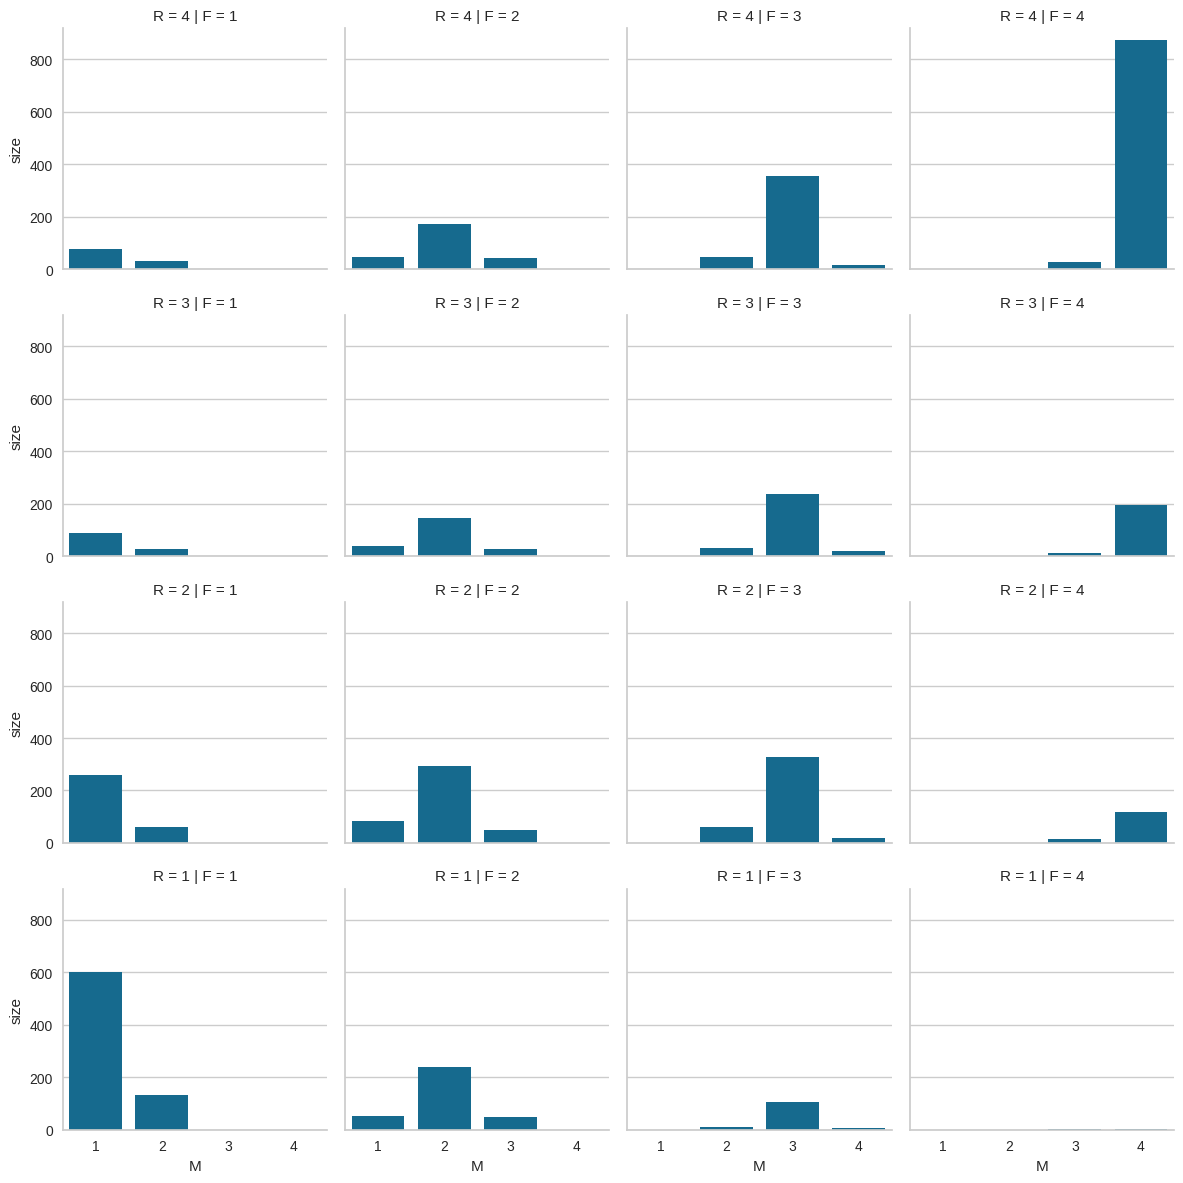

In [80]:
g = sns.FacetGrid(
    data = rfm_bar_data,
    col = "F",
    row = "R"
)
g.map(sns.barplot, "M", "size");

**Recency, Frequency, and Monetary Distribution**

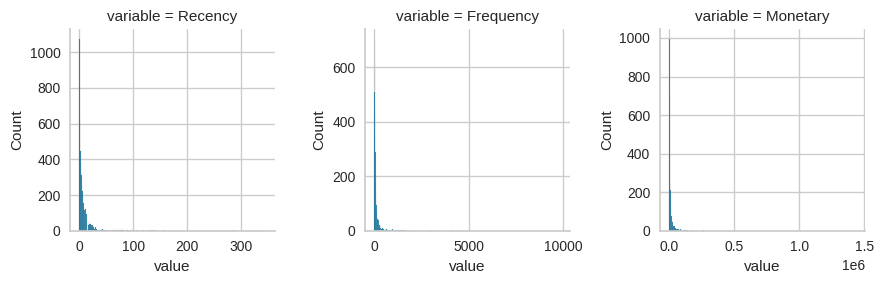

In [81]:
g = sns.FacetGrid(
    data = pd.melt(
     rfm[["Recency", "Frequency","Monetary"]],
     value_vars=["Recency","Frequency", "Monetary"]
    ),
    col = "variable",
    sharex = False,
    sharey = False
)
g.map(sns.histplot, "value");

**RFM Score to RFM Segment**

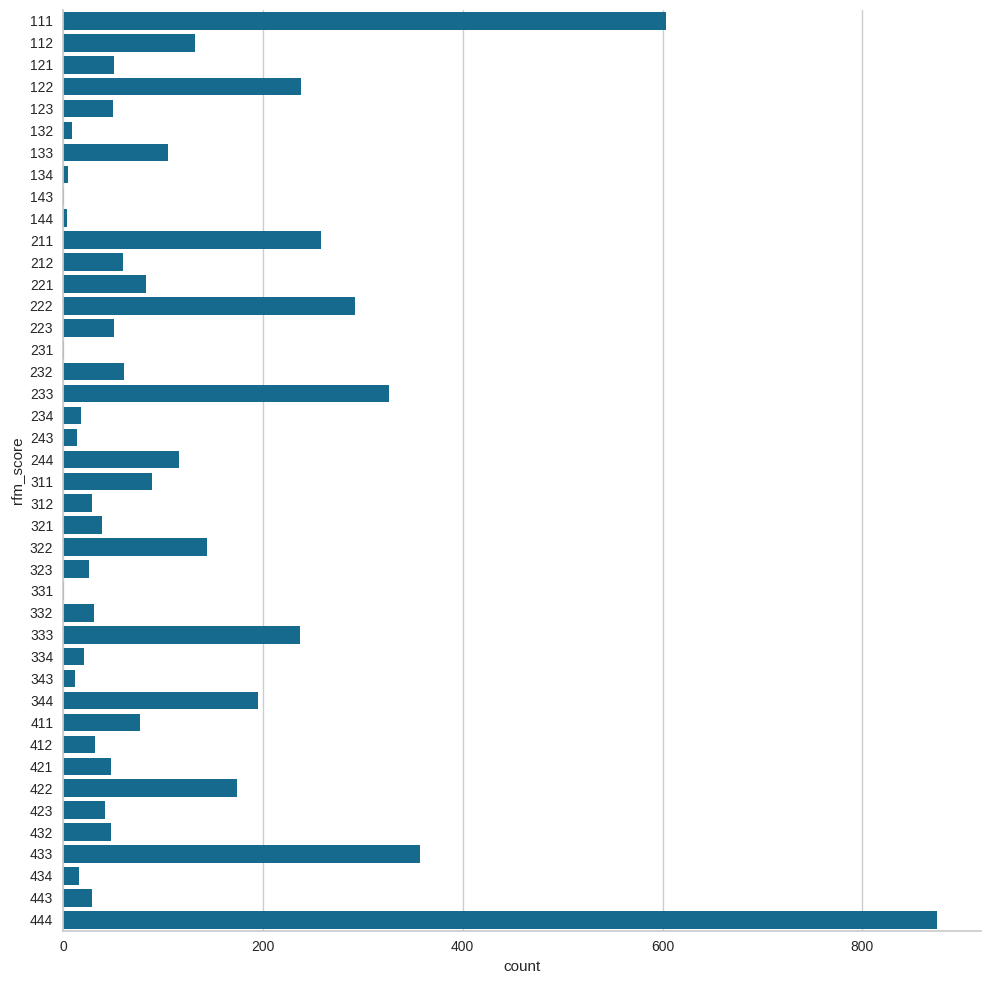

In [82]:
sns.catplot(
    y = "rfm_score",
    data = rfm.sort_values(by = ["rfm_score"], axis = 0),
    kind = "count",
    height = 10
)

# K-Means Clustering

Check data for model

In [83]:
rfm

,customerId,Recency,Frequency,Monetary,R,F,M,rfm_score
0,100547107,0,84,10950.11,4,3,3,433
1,100634414,5,22,1500.86,2,2,1,221
2,100973869,8,45,6086.33,2,2,3,223
3,101192712,5,20,592.68,2,1,1,211
4,101548993,13,29,1555.24,1,2,1,121
...,...,...,...,...,...,...,...,...
4995,999273501,1,8,78.94,4,1,1,411
4996,999275549,0,225,31757.82,4,4,4,444
4997,999789077,2,69,7102.10,3,3,3,333
4998,999984515,2,32,2893.21,3,2,2,322


Data standarization using StandardScaler

In [84]:
scaler_obj = StandardScaler()
scaled_data = scaler_obj.fit_transform(rfm[["Recency", "Frequency", "Monetary"]].to_numpy())
data_for_kmeans = pd.DataFrame(scaled_data, columns = ["Recency", "Frequency", "Monetary"])

Check standardize data

In [85]:
data_for_kmeans

,Recency,Frequency,Monetary
0,-0.406835,-0.123769,-0.123859
1,-0.194326,-0.308062,-0.317832
2,-0.066821,-0.239696,-0.223702
3,-0.194326,-0.314007,-0.336475
4,0.145687,-0.287255,-0.316716
...,...,...,...
4995,-0.364333,-0.349677,-0.347021
4996,-0.406835,0.295349,0.303280
4997,-0.321832,-0.168356,-0.202850
4998,-0.321832,-0.278338,-0.289250


## K-Means Modeling

Create clusters using k-means by setting k = 3

In [86]:
kmeans_model = KMeans(
    n_clusters = 3,
    random_state=1000
)

kmeans_model.fit(data_for_kmeans)

KMeans(n_clusters=3, random_state=1000)

In [87]:
np.unique(kmeans_model.labels_, return_counts = True)

(array([0, 1, 2], dtype=int32), array([4842,   28,  130]))

In [88]:
rfm["cluster"] = kmeans_model.labels_

## Post-Modeling Analysis

In [89]:
rfm

,customerId,Recency,Frequency,Monetary,R,F,M,rfm_score,cluster
0,100547107,0,84,10950.11,4,3,3,433,0
1,100634414,5,22,1500.86,2,2,1,221,0
2,100973869,8,45,6086.33,2,2,3,223,0
3,101192712,5,20,592.68,2,1,1,211,0
4,101548993,13,29,1555.24,1,2,1,121,0
...,...,...,...,...,...,...,...,...,...
4995,999273501,1,8,78.94,4,1,1,411,0
4996,999275549,0,225,31757.82,4,4,4,444,0
4997,999789077,2,69,7102.10,3,3,3,333,0
4998,999984515,2,32,2893.21,3,2,2,322,0


Total users per segment

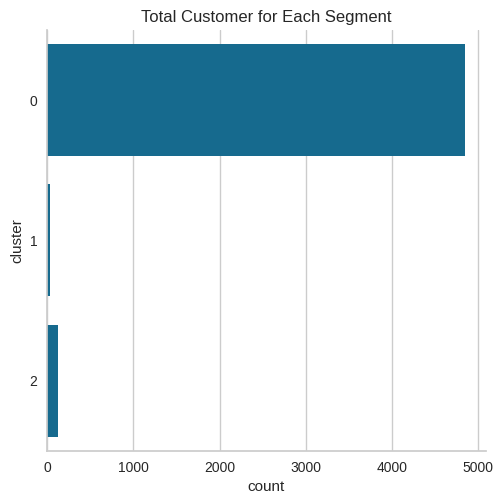

In [90]:
sns.catplot(
    y = "cluster",
    data = rfm,
    kind = "count",
    height = 5
).ax.set_title("Total Customer for Each Segment");

**Recency Days Distribution of Each Segment**

<Axes: xlabel='cluster', ylabel='Recency'>

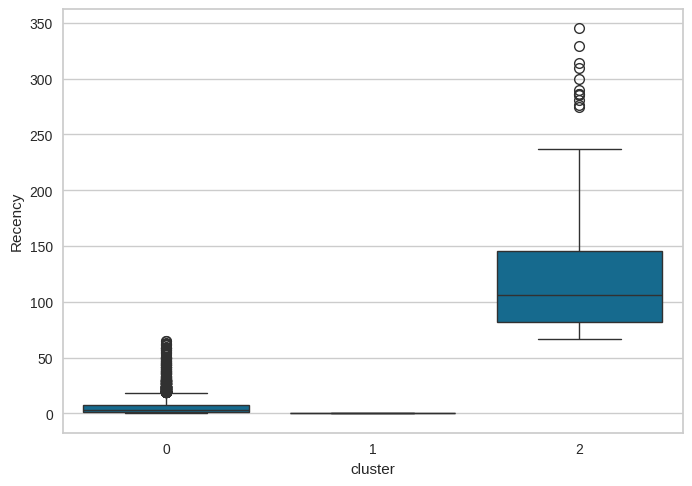

In [91]:
sns.boxplot(x = 'cluster', y = 'Recency', data = rfm)

**Transaction Frequency Distribution of Each Segment**

<Axes: xlabel='cluster', ylabel='Frequency'>

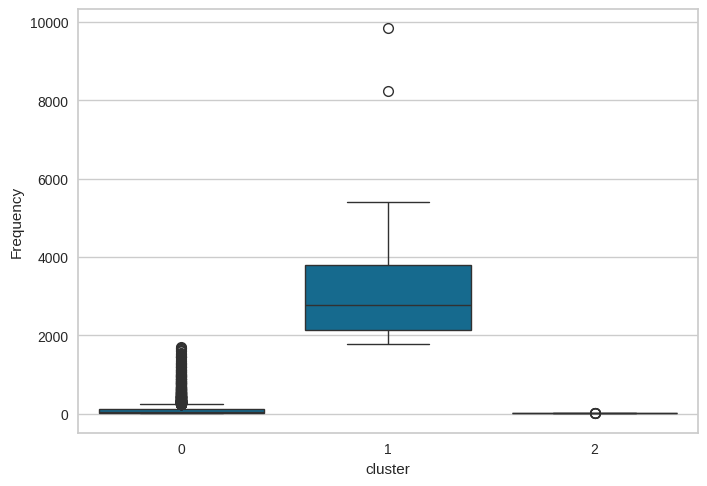

In [92]:
sns.boxplot(x = 'cluster', y = 'Frequency', data = rfm)

**Monetary Distribution of Each Segment**

<Axes: xlabel='cluster', ylabel='Monetary'>

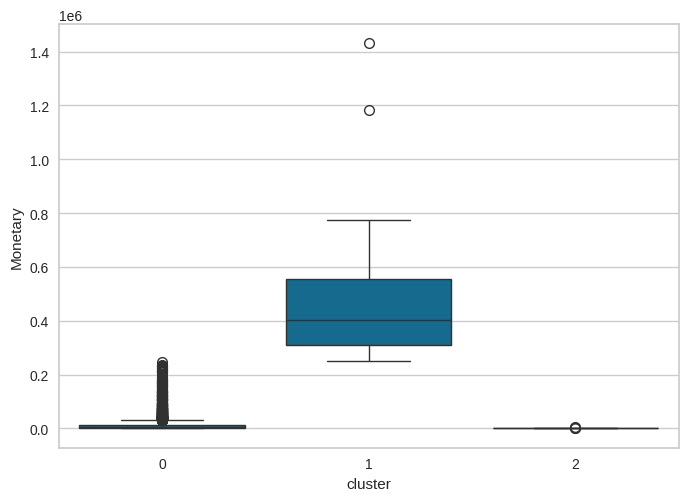

In [93]:
sns.boxplot(x = 'cluster', y = 'Monetary', data = rfm)

## Cluster Evaluation

**Elbow Method**

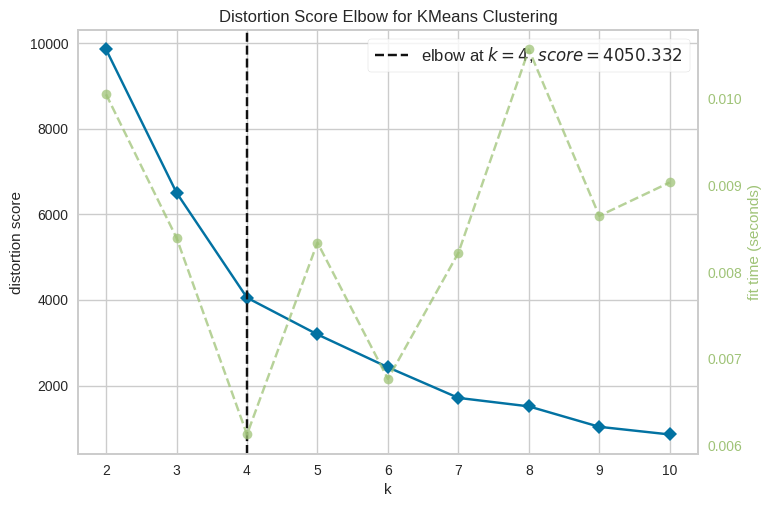

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [94]:
model = KElbowVisualizer(KMeans(random_state=1000), k=10)
model.fit(data_for_kmeans)
model.show()

Silhouette Score: 0.81319087177001
Calinski-Harabasz Index: 4521.86309220543
Davies-Bouldin Index: 0.49800276957939194


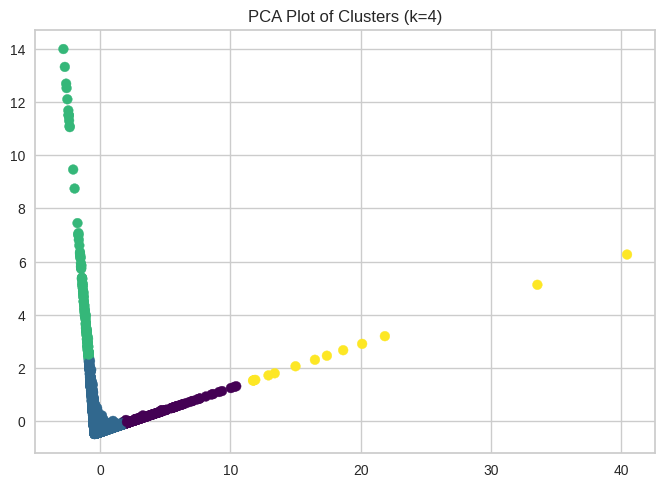

In [95]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(data_for_kmeans)


print("Silhouette Score:", silhouette_score(data_for_kmeans, labels))
print("Calinski-Harabasz Index:", calinski_harabasz_score(data_for_kmeans, labels))
print("Davies-Bouldin Index:", davies_bouldin_score(data_for_kmeans, labels))


pca = PCA(n_components=2)
X_pca = pca.fit_transform(data_for_kmeans)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
plt.title("PCA Plot of Clusters (k=4)")
plt.show()

In [96]:
from collections import Counter
print("Ukuran tiap cluster:", Counter(labels))

cluster_centers = kmeans.cluster_centers_
feature_names = ["Recency", "Frequency", "Monetary"]
feature_means_per_cluster = pd.DataFrame(cluster_centers,
                                         columns=feature_names)
print("Rata-rata fitur per cluster:")
print(feature_means_per_cluster)

Ukuran tiap cluster: Counter({np.int32(1): 4677, np.int32(0): 181, np.int32(2): 128, np.int32(3): 14})
Rata-rata fitur per cluster:
    Recency  Frequency   Monetary
0 -0.401904   2.678857   2.692567
1 -0.120918  -0.133240  -0.134348
2  5.031063  -0.355529  -0.330887
3 -0.406835  13.128340  13.096024


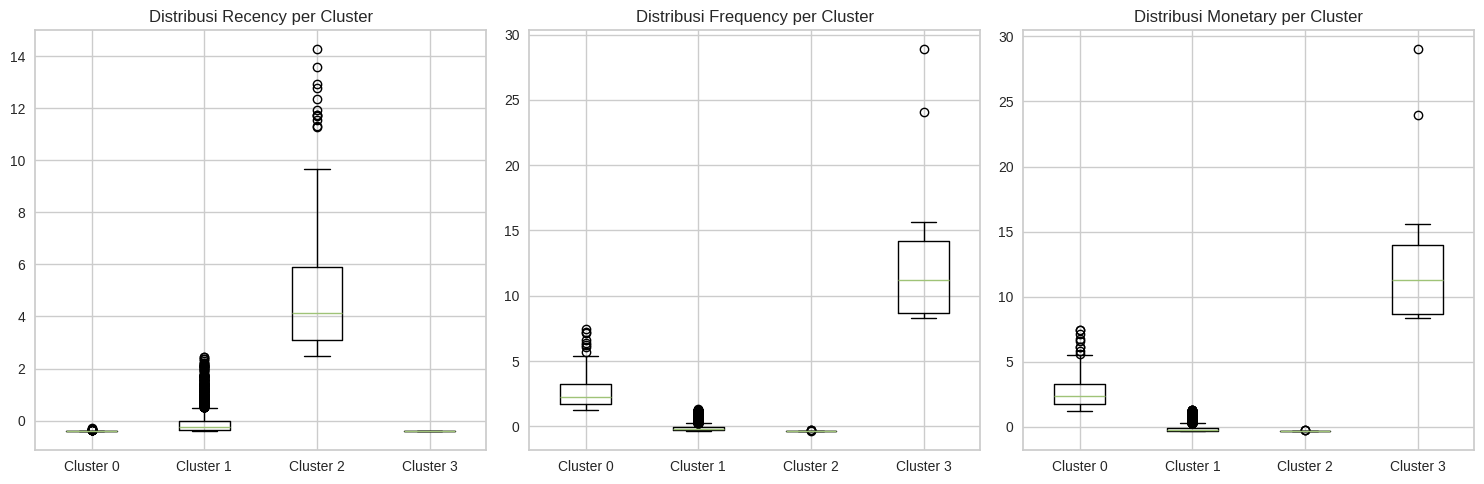

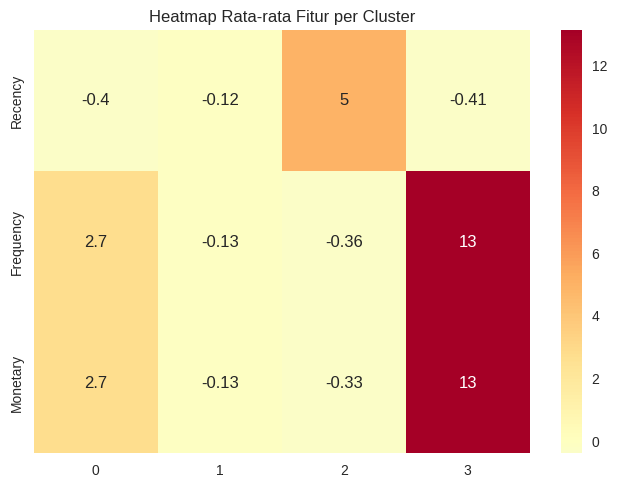

In [97]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, feature in enumerate(feature_names):
    ax = axes[i]
    data = []
    for cluster in range(4):
        data.append(data_for_kmeans.values[labels==cluster, i])
    ax.boxplot(data)
    ax.set_title(f'Distribusi {feature} per Cluster')
    ax.set_xticklabels([f'Cluster {c}' for c in range(4)])
plt.tight_layout()
plt.show()

import seaborn as sns
sns.heatmap(feature_means_per_cluster.T, cmap='RdYlBu_r',
            annot=True, center=0)
plt.title('Heatmap Rata-rata Fitur per Cluster')
plt.show()

In [98]:
profit_analysis_df = rfm[['customerId', 'Monetary']].copy()
profit_analysis_df = profit_analysis_df.sort_values(by='Monetary', ascending=False).reset_index(drop=True)

total_gmv = profit_analysis_df['Monetary'].sum()
total_customers = len(profit_analysis_df)

profit_analysis_df['Cumulative_GMV'] = profit_analysis_df['Monetary'].cumsum()
profit_analysis_df['Num_Customers'] = range(1, total_customers + 1)

profit_analysis_df['Percentage_Customers'] = (profit_analysis_df['Num_Customers'] / total_customers) * 100
profit_analysis_df['Percentage_GMV'] = (profit_analysis_df['Cumulative_GMV'] / total_gmv) * 100
profit_analysis_df['Lift'] = profit_analysis_df['Percentage_GMV'] / profit_analysis_df['Percentage_Customers']

profit_analysis_df.head()

,customerId,Monetary,Cumulative_GMV,Num_Customers,Percentage_Customers,Percentage_GMV,Lift
0,318001076,1429846.84,1429846.84,1,0.02,1.683780,84.188997
1,456044564,1182535.23,2612382.07,2,0.04,3.076327,76.908177
2,812328116,775683.36,3388065.43,3,0.06,3.989768,66.496127
3,838085703,708597.90,4096663.33,4,0.08,4.824209,60.302609
4,239875038,666872.15,4763535.48,5,0.10,5.609514,56.095137


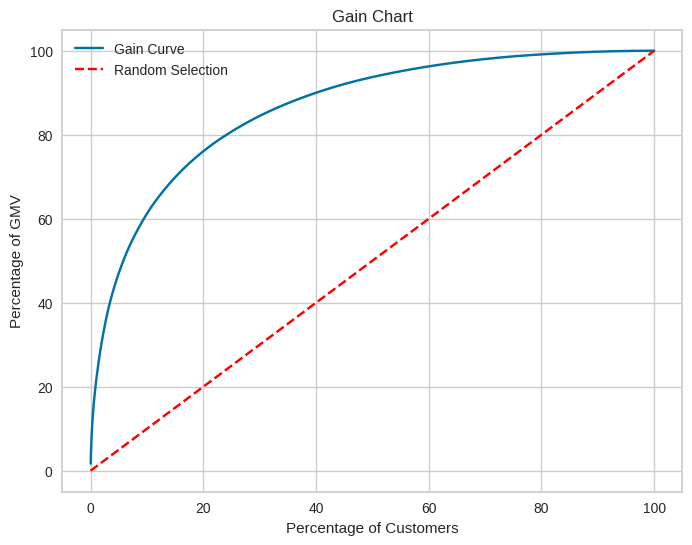

In [99]:
plt.figure(figsize=(8, 6))
sns.lineplot(x='Percentage_Customers', y='Percentage_GMV', data=profit_analysis_df, label='Gain Curve')
plt.plot([0, 100], [0, 100], linestyle='--', color='red', label='Random Selection')
plt.xlabel('Percentage of Customers')
plt.ylabel('Percentage of GMV')
plt.title('Gain Chart')
plt.legend()
plt.grid(True)
plt.show()

In [100]:
def analyze_cluster_profitability(df_clean, cluster_id):
    """
    Menganalisis profitabilitas dan karakteristik pelanggan untuk cluster tertentu.

    Args:
        df (pd.DataFrame): DataFrame yang berisi data pelanggan dengan kolom 'cluster',
                            'GMV', 'Recency', dan 'Frequency'.
        cluster_id (int): ID cluster yang ingin dianalisis.

    Returns:
        pd.DataFrame: Ringkasan metrik profitabilitas untuk cluster yang diminta.
    """
    cluster_data = df_clean[df_clean['cluster'] == cluster_id]

    if cluster_data.empty:
        print(f"Tidak ada data untuk Cluster {cluster_id}.")
        return pd.DataFrame()

    total_customers = len(cluster_data)
    total_gmv = cluster_data['Monetary'].sum()
    avg_gmv_per_customer = cluster_data['Monetary'].mean()
    avg_recency = cluster_data['Recency'].mean()
    avg_frequency = cluster_data['Frequency'].mean()

    summary = pd.DataFrame({
        'Metric': [
            'Jumlah Pelanggan',
            'Total Monetary',
            'Rata-rata Monetary per Pelanggan',
            'Rata-rata Recency (Hari Sejak Pembelian Terakhir)',
            'Rata-rata Frekuensi (Jumlah Transaksi)'
        ],
        'Value': [
            total_customers,
            f'{total_gmv:,.2f}',
            f'{avg_gmv_per_customer:,.2f}',
            f'{avg_recency:.2f}',
            f'{avg_frequency:.2f}'
        ]
    })
    return summary

print("Analisis Profitabilitas untuk Cluster 0:")
display(analyze_cluster_profitability(rfm, 0))

print("\nAnalisis Profitabilitas untuk Cluster 1:")
display(analyze_cluster_profitability(rfm, 1))

print("\nAnalisis Profitabilitas untuk Cluster 2:")
display(analyze_cluster_profitability(rfm, 2))

Analisis Profitabilitas untuk Cluster 0:


,Metric,Value
0,Jumlah Pelanggan,4842
1,Total Monetary,"71,270,456.37"
2,Rata-rata Monetary per Pelanggan,"14,719.22"
3,Rata-rata Recency (Hari Sejak Pembelian Terakhir),6.47
4,Rata-rata Frekuensi (Jumlah Transaksi),110.28



Analisis Profitabilitas untuk Cluster 1:


,Metric,Value
0,Jumlah Pelanggan,28
1,Total Monetary,"13,535,505.98"
2,Rata-rata Monetary per Pelanggan,"483,410.93"
3,Rata-rata Recency (Hari Sejak Pembelian Terakhir),0.00
4,Rata-rata Frekuensi (Jumlah Transaksi),3337.50



Analisis Profitabilitas untuk Cluster 2:


,Metric,Value
0,Jumlah Pelanggan,130
1,Total Monetary,"112,904.15"
2,Rata-rata Monetary per Pelanggan,868.49
3,Rata-rata Recency (Hari Sejak Pembelian Terakhir),127.01
4,Rata-rata Frekuensi (Jumlah Transaksi),6.08


## **Actionable Insights**

### Combining RFM and K-Means Insights

By integrating the RFM segmentation with the K-Means clustering results, we can paint a comprehensive picture of our customer base and extract powerful, actionable insights. The RFM scores provide a granular view based on Recency, Frequency, and Monetary values, while K-Means groups customers into broader, distinct behavioral segments.

Here’s a synthesis of the findings:

**1. Elite/Top-Tier Customers (K-Means Cluster 3):**
*   **RFM Profile:** These customers likely correspond to the highest RFM scores (e.g., 444). They exhibit extremely low Recency (most recent purchases), extremely high Frequency (most transactions), and extremely high Monetary value (highest spending).
*   **Insights:** This is our **most valuable segment**, though small in number. They are highly engaged, loyal, and contribute disproportionately to GMV. They are critical for the business's sustained profitability.
*   **Actionable Strategy:** Foster loyalty through exclusive offers, VIP programs, personalized service, and early access to new features or products. Conduct surveys to understand their needs and preferences, and leverage them as advocates or for testimonials.

**2. High-Value Active Customers (K-Means Cluster 0):**
*   **RFM Profile:** These customers also have strong RFM scores, perhaps slightly lower than the Elite tier (e.g., 434, 443, 344). They are recent, frequent, and high-spending.
*   **Insights:** This is a substantial segment of **consistently valuable and engaged customers**. They are less extreme than the 'Elite' group but represent a significant portion of active, high-contributing customers. They are prime candidates for retention and growth.
*   **Actionable Strategy:** Implement targeted campaigns for upselling or cross-selling relevant credit card products or services. Offer loyalty points or rewards for continued spending. Personalize communications based on their transaction history and merchant preferences to encourage higher engagement and spending.

**3. Average/Mid-Tier Customers (K-Means Cluster 1):**
*   **RFM Profile:** This cluster represents a broad range of average RFM scores (e.g., 222, 323, 232). Their recency, frequency, and monetary values are moderate.
*   **Insights:** This is the **largest customer segment** and forms the backbone of the customer base. They are engaged but have room for growth. Understanding their varied behaviors is key to moving them up the value chain.
*   **Actionable Strategy:** Develop segmented marketing campaigns to encourage specific behaviors. For customers with lower frequency, offer incentives for repeat purchases. For those with lower monetary value, suggest using their card for a wider range of transactions or higher-value purchases. Implement educational content on card benefits.

**4. Churned/At-Risk Customers (K-Means Cluster 2):**
*   **RFM Profile:** These customers typically have low Recency (e.g., 1xx), indicating a long time since their last transaction, coupled with low Frequency and Monetary scores.
*   **Insights:** This segment comprises customers who are **disengaged, inactive, or have potentially churned**. They pose a risk to the customer base and may require specific re-engagement efforts, or they might be deprioritized if the cost of re-engagement outweighs potential return.
*   **Actionable Strategy:** Initiate win-back campaigns with attractive offers (e.g., special cash back, waived fees for a period) to reactivate them. Understand the reasons for their inactivity through surveys or feedback channels. For those with extremely low potential, focus resources on more promising segments.

### Overall Business Insights:

*   **Value Concentration:** The Gain Chart clearly demonstrated that a small percentage of customers contribute to a disproportionately large percentage of the total GMV. This highlights the importance of identifying and nurturing the top-tier segments.
*   **Behavioral Patterns:** Transaction patterns (e.g., day vs. night, merchant categories) can further refine segmentation and offer insights into customer lifestyles, enabling more personalized service and targeted fraud detection.
*   **Fraud Detection:** By understanding typical transaction behaviors within segments, anomalies (e.g., a 'mid-tier' customer suddenly making 'elite' level transactions in unusual categories or times) can be more easily flagged as potential fraud.

These insights are crucial for tailoring marketing efforts, managing risk, and enhancing customer satisfaction across the entire customer lifecycle.